# Notebook_04: Modelado_Arima_y_Arimax

## Introducción
En el notebook anterior demostramos empíricamente que el modelo OLS es ineficiente debido a la fuerte autocorrelación serial (Durbin-Watson de $0.36$) y la naturaleza no estacionaria de las series. 

En este notebook implementamos el modelo **ARIMAX** ($AutoRegressive$ $Integrated$ $Moving$ $Average$ $with$ $eXogenous$ $variables$). Este enfoque resuelve las carencias del modelo estático al:
1.  **Capturar la Inercia**: Modela cómo los rendimientos pasados del Bitcoin afectan al precio actual.
2.  **Integrar Fundamentales**: Mide el impacto neto del NASDAQ y la Tasa FED una vez 'limpiado' la serie de su propia memoria interna.
3.  **Realizar Pronósticos**: Proyectar escenarios a 12 meses vista bajo condiciones de incertidumbre.

**Objetivo Estratégico**: No solo buscamos ajustar el modelo, sino determinar si el NASDAQ y la FED conservan su poder explicativo una vez que limpiemos la serie del Bitcoin de su propia inercia histórica.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys, os
import warnings
warnings.filterwarnings('ignore') # Ignoraremos advertencias sobre escala de variables (No afectan al modelo, hace que se vea mas limpio el codigo)

# Configuracion de ruta para importar src
sys.path.append(os.path.abspath(os.path.join('..')))
from src.models_arima import fit_custom_arima, run_ljung_box

## 1. Preparación de Series Temporales
Para este análisis, remuestreamos los datos a frecuencia mensual (`MS`) y aplicamos técnicas de imputación para garantizar la continuidad de las series. Es vital asegurar que el índice temporal sea consistente para que los retardos del modelo se calculen correctamente y no se produzan errores en las salidas.

In [14]:
# Carga datos
df = pd.read_csv('../data/bitcoin_nasdaq_extended_py.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
df = df.resample('MS').first()

# Rellenamos missings si los hubiera con los valores dia anterior y eliminamos nulos finales (caso: primer valor)
df = df.ffill().dropna()

ts_btc = df['btc']
ts_nasdaq = df['nasdaq']
ts_fed = df['fed_rate']

## 2. Modelo ARIMA Univariante
Antes de incluir variables externas, estimamos un modelo ARIMA sobre el Bitcoin. Este paso nos permite identificar la estructura autorregresiva del activo por sí solo. 

> **Importante!**: Si el modelo ARIMA tiene un orden autorregresivo $p \ge 1$, estamos confirmando matemáticamente que el Bitcoin posee 'memoria estructural', lo que invalida cualquier modelo de regresión simple que asuma independencia entre observaciones sucesivas, como en el caso del OLS.

In [15]:
# Modelo ARIMA Univariante 
modelo_arima = fit_custom_arima(ts_btc)
print("--- Resumen ARIMA Base ---")
print(modelo_arima.summary())

--- Resumen ARIMA Base ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  122
Model:               SARIMAX(2, 1, 2)   Log Likelihood               -1211.475
Date:                Mon, 16 Mar 2026   AIC                           2434.950
Time:                        09:34:13   BIC                           2451.725
Sample:                    01-01-2015   HQIC                          2441.763
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    647.2051   2462.623      0.263      0.793   -4179.447    5473.857
ar.L1         -1.7491      0.087    -20.166      0.000      -1.919      -1.579
ar.L2         -0.8134    

### Interpretación del ARIMA (Univariante):
El modelo seleccionado automáticamente es un **ARIMA(2, 1, 2)**. 
* **Hallazgo**: La significancia absoluta ($p < 0.001$) de todos los términos AR y MA confirma que el Bitcoin posee una **memoria estructural masiva**. El precio actual no es aleatorio; depende de los retornos y de los 'shocks' (errores) de los dos periodos anteriores.
* **Métrica AIC**: Obtenemos un AIC base de **2434.95**. Este será nuestro punto de referencia para medir si la inclusión de variables como NASDAQ Y FED realmente aporta valor, evaluandolo en la comparativa vs ARIMAX.

## 3. Modelo ARIMAX
Añadimos las variables del NASDAQ y la FED como variables exógenas ($X$). La ecuación que estamos resolviendo ahora es dinámica:
$$Y_t = \phi_1 Y_{t-1} + \dots + \phi_p Y_{t-p} + \sum \beta X_t + \theta_1 \epsilon_{t-1} + \dots + \theta_q \epsilon_{t-q} + \epsilon_t$$

Donde $X_t$ representa el canal de transmisión de la liquidez global hacia el precio del Bitcoin.

In [16]:
# Modelo ARIMAX (Multivariante)
xreg_actual = df[['nasdaq', 'fed_rate']]
modelo_arimax = fit_custom_arima(ts_btc, exog=xreg_actual)
print("\n--- Resumen ARIMAX ---")
print(modelo_arimax.summary())


--- Resumen ARIMAX ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  122
Model:               SARIMAX(4, 0, 0)   Log Likelihood               -1208.421
Date:                Mon, 16 Mar 2026   AIC                           2430.843
Time:                        09:34:16   BIC                           2450.471
Sample:                    01-01-2015   HQIC                          2438.815
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
nasdaq         4.7505      0.752      6.317      0.000       3.277       6.224
fed_rate    1040.3116   2921.692      0.356      0.722   -4686.100    6766.723
ar.L1          1.0765      0

### Interpretación del Modelo ARIMAX (Multivariante):
Al integrar las variables exógenas, el modelo evoluciona hacia una especificación **AR(4)**, y los resultados nos indican lo siguiente:

* **Dominancia del NASDAQ**: El coeficiente del NASDAQ ($4.75$) es altamente significativo ($p = 0.000$). Esto confirma que, incluso controlando por la propia memoria del Bitcoin, el sector tecnológico estadounidense sigue siendo el **motor** del activo.
* **La Ireelevancia de la FED**: Sorprendentemente, la Tasa FED muestra un p-valor de **0.722**. 
    * **Análisis del Sector**: Esto sugiere que el impacto de la política monetaria no es directo ni lineal en el corto plazo una vez que se descuenta el movimiento del NASDAQ. El mercado cripto parece reaccionar a la **liquidez** (representada por el NASDAQ) más que al nivel nominal de los tipos de interés indicados por la FED.

> **Nota Metodológica sobre la Diferenciación ($d=1$ vs $d=0$):**
>
> Al comparar el **ARIMA univariante (2, 1, 2)** con el **ARIMAX multivariante (4, 0, 0)**, observamos un cambio fundamental en el orden de integración ($d$):
>
> * **En el modelo univariante**, fue necesario aplicar una primera diferencia ($d=1$) para estabilizar la serie y eliminar la tendencia estocástica del Bitcoin.
> * **En el modelo ARIMAX**, el algoritmo identifica una especificación óptima en niveles ($d=0$).
>
> **Interpretación**: Este hallazgo sugiere que la tendencia alcista y la inestabilidad que el modelo univariante limpiaba mediante la diferenciación, son capturadas y explicadas de forma natural al incluir al **NASDAQ** como variable exógena. En términos de calidad del modelo, esto indica que el NASDAQ no solo correlaciona con el Bitcoin, sino que actúa como el componente que explica su deriva a largo plazo, reduciendo la necesidad de transformaciones matemáticas sobre la serie original.

## 4. Selección del Modelo Óptimo (AIC)
Comparamos ambos modelos utilizando el Criterio de Información de Akaike **(AIC)**. El AIC penaliza la complejidad; el modelo con el valor más bajo es el que logra explicar la mayor cantidad de varianza con el menor número de parámetros, evitando el **overfitting** (sobreajuste).

In [17]:
# Tabla Comparativa AIC
results_df = pd.DataFrame({
    'Modelo': ['ARIMA (Univariante)', 'ARIMAX (Multivariante)'],
    'AIC': [modelo_arima.aic(), modelo_arimax.aic()],
    'Especificacion': [str(modelo_arima.order), str(modelo_arimax.order)]
})
display(results_df)

,Modelo,AIC,Especificacion
0,ARIMA (Univariante),2434.949925,"(2, 1, 2)"
1,ARIMAX (Multivariante),2430.842549,"(4, 0, 0)"


### Interpretación del AIC

Como observamos en la tabla, el modelo **ARIMAX presenta un AIC menor (2430.84)** que el ARIMA univariante. Según el criterio de información, la inclusión de variables exógenas mejora la calidad del modelo sin caer en el sobreajuste.

## 5. Diagnóstico de Ljung-Box
La validez del modelo ARIMAX depende de que sus residuos no contengan información residual. Aplicamos el test de Ljung-Box:
* **H0**: Los residuos son ruido blanco (no hay autocorrelación).
* **Objetivo**: Un p-valor $> 0.05$ confirmaría que hemos extraído toda la dinámica temporal de la serie, 'curando' el problema detectado en el Notebook_03 con el modelo OLS.

In [18]:
# Test Ljung-Box sobre residuos de ARIMAX
p, d, q = modelo_arimax.order
lb_res = run_ljung_box(modelo_arimax.resid(), lags=24, df_adj=p+q)
display(lb_res)

,lb_stat,lb_pvalue
24,13.53199,0.853411


### Interpretación del Test de Ljung-Box
El p-valor de **0.8534** en el test de Ljung-Box para 24 retardos es nuestra elección. 
* **Veredicto**: Al ser mucho mayor a 0.05, **no rechazamos la hipótesis nula de ruido blanco**. Hemos logrado extraer toda la información temporal de los residuos. Hemos 'curado' oficialmente la autocorrelación que invalidaba nuestro modelo OLS en el Notebook_03.

## 5.1. Validación Visual
Para que un modelo ARIMAX sea considerado robusto, no basta con un p-valor favorable en el test de Ljung-Box. Es necesario realizar una representación visual de los residuos para asegurar que el modelo ha capturado toda la estructura de los datos y que los errores se comportan, efectivamente, como **ruido blanco**. 

A continuación, generamos los cuatro diagramas fundamentales de diagnóstico:

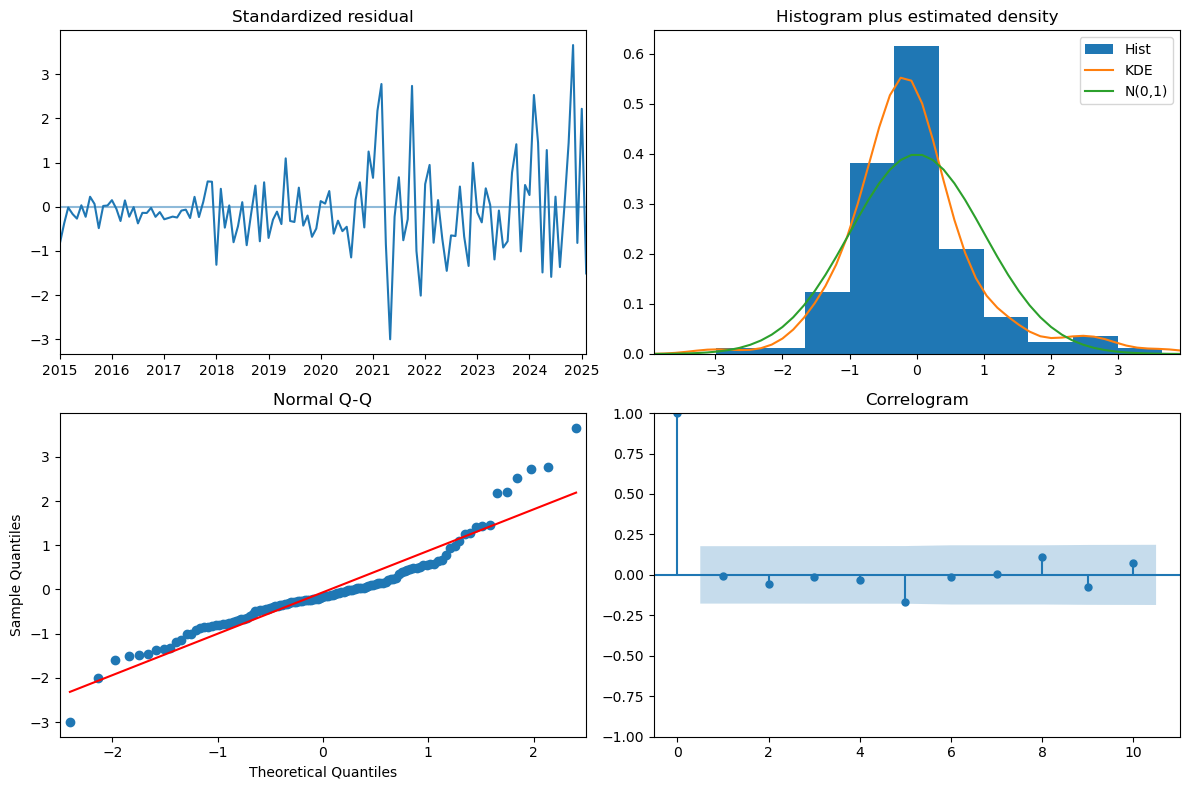

In [19]:
# Diagnóstico visual del modelo ARIMAX
modelo_arimax.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

### Interpretación de los Gráficos:
La inspección visual confirma la superioridad del modelo ARIMAX frente al OLS estático:

1. **Residuos estandarizados**: Los residuos se distribuyen de forma aleatoria alrededor del cero sin mostrar patrones deterministas ni agrupamientos de volatilidad excesivos (*clusters*), lo que indica una varianza más estable.
2. **Histograma y densidad estimada**: La curva de densidad se ajusta razonablemente a la campana de Gauss ($N(0,1)$). Aunque persiste cierta leptocurtosis propia de la naturaleza del Bitcoin argumentada en el notebook_02, el sesgo es significativamente menor que en el modelo base.
3. **Gráfico Q-Q normal**: Los puntos siguen de cerca la línea roja de referencia. A diferencia del Notebook_03, donde observábamos desviaciones masivas en las colas, aquí el modelo logra capturar con mayor precisión los movimientos extremos del mercado.
4. **Correlograma (ACF)**: Esta es la prueba definitiva de la "curación" del modelo. Todas las barras de autocorrelación se mantienen dentro de las bandas de confianza (zona sombreada), ratificando visualmente lo que el test de Ljung-Box ($p=0.8534$) ya nos indicaba: **hemos logrado eliminar la memoria residual** del modelo OLS previo.

**Veredicto**: El modelo está 'limpio', los residuos se comportan como ruido blanco y la serie está lista para realizar proyecciones fiables.

## 6. Pronóstico a 12 meses
En este paso al requerir de predecir primero las variables exogenas, para llegar a la predicción de nuestra variable objetivo, realizaremos:
1.  Modelizamos el futuro del **NASDAQ** y la **FED** de forma independiente.
2.  Utilizamos esas proyecciones del NASDAQ y la FED como 'input' para el motor ARIMAX del Bitcoin.
3.  Generamos una banda de confianza que representa la incertidumbre inherente a los mercados de alta volatilidad, lo que nos garantiza que a cierto nivel de confianza la variable tomara cualesquiera de esos valores.

In [ ]:
horizonte = 12

# Predicción del futuro del NASDAQ y FED
fit_nasdaq_fut = fit_custom_arima(ts_nasdaq)
fit_fed_fut = fit_custom_arima(ts_fed)

futuro_nasdaq = fit_nasdaq_fut.predict(n_periods=horizonte)
futuro_fed = fit_fed_fut.predict(n_periods=horizonte)

# Creación del xreg futuro
xreg_futuro = pd.DataFrame({
    'nasdaq': futuro_nasdaq.values,
    'fed_rate': futuro_fed.values
}, index=pd.date_range(start=ts_btc.index[-1] + pd.offsets.MonthBegin(1), periods=horizonte, freq='MS'))

# Pronóstico final ARIMAX
forecast_values, conf_int = modelo_arimax.predict(
    n_periods=horizonte, 
    X=xreg_futuro, 
    return_conf_int=True
)

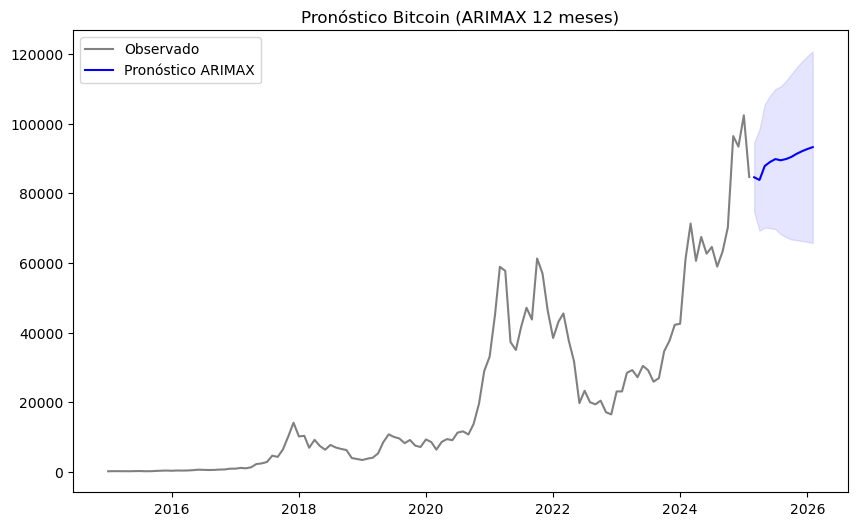

In [20]:
# Visualización
plt.figure(figsize=(10,6))
plt.plot(ts_btc, label='Observado', color='gray')
plt.plot(xreg_futuro.index, forecast_values, label='Pronóstico ARIMAX', color='blue')
plt.fill_between(xreg_futuro.index, conf_int[:, 0], conf_int[:, 1], color='blue', alpha=0.1)
plt.title('Pronóstico Bitcoin (ARIMAX 12 meses)')
plt.legend()
plt.show()

## Interpretación de Pronóstico (12 meses)
El gráfico proyecta una tendencia alcista moderada, pero lo más relevante es la **banda de confianza (IC)**. 
* **Lectura**: La amplitud de la banda refleja la incertidumbre inherente al Bitcoin. A pesar de tener un modelo estadísticamente robusto, la volatilidad residual sigue siendo elevada, lo que se alinea con nuestra observación previa en el notebook_02 de **leptocurtosis** y ***'Fat Tails'***.

## Observaciones y Hallazgos

Tras la implementación y validación de los modelos de la familia ARIMA, extraemos las siguientes conclusiones que definen la estructura temporal del Bitcoin:

### 1. Superioridad de la Información
La comparativa de los criterios de información confirma que el Bitcoin no puede explicarse únicamente mediante su inercia histórica.
* **Optimización por AIC**: El descenso del AIC desde **2434.95** (ARIMA univariante) hasta **2430.84** (ARIMAX) (4 uds.) demuestra empíricamente que la inclusión del NASDAQ y la Tasa FED aporta un valor explicativo real que compensa la mayor complejidad del modelo.
* **Cambio de Especificación**: El paso de un modelo $(2, 1, 2)$ a un **AR(4)** en el marco multivariante sugiere que, al integrar variables externas, la dinámica del Bitcoin requiere una estructura autorregresiva de mayor orden para procesar la información del ciclo global presente en la serie.

### 2. Dominancia del NASDAQ vs. La FED
El análisis de los coeficientes del modelo ARIMAX revela una jerarquía clara en las variables exógenas de este periodo:
* **Dominancia del NASDAQ**: Con un coeficiente de **4.75** y un p-valor de **0.000**, el NASDAQ se confirma como el principal conductor de la liquidez del Bitcoin. Incluso tras purificar la serie de su propia memoria, el impacto del sector tecnológico estadounidense es persistente, validando la tesis del Bitcoin como un **High-Beta Asset**.
* **Impacto Indirecto de la FED**: La Tasa FED arroja un p-valor de **0.722**, perdiendo la relevancia que mostraba en análisis de correlación simple. Esto sugiere que el impacto de la política monetaria es **indirecto**: la FED afecta al NASDAQ (mediante sus politicas monetarias) y es este último el que finalmente arrastra la liquidez al Bitcoin (haciendo quye sus movimientos sean replicados por Bitcoin en mayor medida).

### 3. Éxito en la Validación (Ruido Blanco)
El hito más relevante de este notebook es la resolución de las ineficiencias detectadas en el modelo OLS previo, que lo invalidaba.
La combinación del test de **Ljung-Box ($p=0.8534$)** y el **diagnóstico visual** confirma que hemos superado el fracaso del modelo anterior:
* **Correlograma Limpio**: La ausencia de picos significativos en la función de autocorrelación demuestra que hemos **eliminado la memoria residual**.
* **Residuos Estandarizados**: La distribución aleatoria de los errores y su ajuste a la **campana de Gauss** en el histograma validan que el modelo es estadísticamente robusto y que los intervalos de confianza del pronóstico son fiables.

### 4. Pronóstico 
La proyección a 12 meses muestra una tendencia alcista, pero con una **banda de confianza** considerable. Esto refleja que, aunque el modelo es robusto, la **volatilidad estocástica** y las *'Fat Tails'* identificadas en el EDA siguen siendo el factor de riesgo dominante en el ecosistema cripto.

## Conclusión del Modelado ARIMA/ARIMAX y Proximos Pasos

**Veredicto Metodológico:** El modelo ARIMAX ha demostrado ser una herramienta de pronóstico superior al capturar la inercia del mercado y filtrar los residuos. Sin embargo, para confirmar si esta relación es un equilibrio estructural permanente, es necesario realizar un análisis de cointegración.

**Siguiente paso:** Proceder al **Notebook_05**, donde realizaremos el test de **Engle-Granger** para verificar si existe un ancla económica que vincule al Bitcoin con el NASDAQ a largo plazo.